In [ ]:
!pip install langchain-openai langchain-community

  Using cached langchain_openai-1.3.2-py3-none-any.whl.metadata (3.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.8/119.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.9/554.9 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.5 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.4.3
    Uninstalling langchain-core-1.4.3:
      Successfully uninstalled langchain-core-1.4.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab

In [ ]:
!pip install pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.3/347.3 kB 6.7 MB/s eta 0:00:00


In [ ]:
!pip install chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.3 MB/s eta 0:00:00
  Attempting uninstall: opentelemetry-proto
    Found existing installation: opentelemetry-proto 1.38.0
    Uninstalling opentelem

In [ ]:
from google.colab import userdata
import os
os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI')

In [ ]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings

loader = PyPDFLoader("/content/tsla (1).pdf")
docs = loader.load()

splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

chunks = splitter.split_documents(docs)

vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=OpenAIEmbeddings(),
    persist_directory="./db"
)

In [ ]:
# Create Retriever Tool

In [ ]:
from langchain.tools import tool

@tool
def rag_search(query: str):
    """
    Search Attention Is All You Need paper
    """

    docs = retriever.invoke(query)

    return "\n\n".join(
        doc.page_content
        for doc in docs
    )

In [ ]:
os.environ['SERPAPI_API_KEY'] = "d74e4673e4de5ebf8b0425afd2a82dfb8272b556c54f8941340798fa0ed64c50"

In [ ]:
# Web Search Tool

In [ ]:
!pip install google-search-results

  Preparing metadata (setup.py) ... done
  Created wheel for google-search-results: filename=google_search_results-2.4.2-py3-none-any.whl size=32010 sha256=7298d028cd288a1d6864e5c7ba3cfda4fd63844504ca7c14133aeaf28d9a3373
  Stored in directory: /root/.cache/pip/wheels/0c/47/f5/89b7e770ab2996baf8c910e7353d6391e373075a0ac213519e
Successfully built google-search-results


In [ ]:
from langchain_community.utilities import SerpAPIWrapper

search = SerpAPIWrapper()

In [ ]:
## Tool (name, description, function)
from langchain.tools import tool

@tool
def google_search(query):
  """Serach Google for latest information on the topic."""
  return search.run(query)

In [ ]:
# ReAct Agent :
# This agent only handles web questions.
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o-mini"
)

web_agent = create_agent(
    model=llm,
    tools=[google_search]
)

In [ ]:
# Router Node :
def router_node(state):

    question = state["messages"][-1].content

    prompt = f"""
    Determine if the question can be answered
    from Attention Is All You Need paper.

    Question:
    {question}

    Return ONLY:
    rag
    or
    web
    """

    result = llm.invoke(prompt).content.strip()

    return {
        "route": result
    }

In [ ]:
# Conditional Routing
def route_decision(state):

    if state["route"] == "rag":
        return "rag_node"

    return "web_node"

In [ ]:
# RAG Node
def rag_node(state):

    question = state["messages"][-1].content

    context = rag_search.invoke(question)

    prompt = f"""
    Answer using only the context.

    Context:
    {context}

    Question:
    {question}
    """

    response = llm.invoke(prompt)

    return {
        "answer": response.content
    }

In [ ]:
# Web ReAct Node
def web_node(state):

    result = web_agent.invoke(
        {
            "messages": state["messages"]
        }
    )

    final_answer = result["messages"][-1].content

    return {
        "answer": final_answer
    }

In [ ]:
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    messages: Annotated[list, add_messages]
    route: str
    answer: str

In [ ]:
# Build Graph
from langgraph.graph import StateGraph
from langgraph.graph import START, END

graph = StateGraph(AgentState)

graph.add_node("router", router_node)
graph.add_node("rag_node", rag_node)
graph.add_node("web_node", web_node)

graph.add_edge(START, "router")
graph.add_conditional_edges(
    "router",
    route_decision,
    {
        "rag_node": "rag_node",
        "web_node": "web_node"
    }
)

graph.add_edge("rag_node", END)
graph.add_edge("web_node", END)

mygraph = graph.compile()

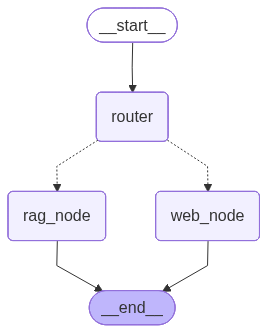

In [ ]:
mygraph

In [ ]:
from langchain_core.messages import HumanMessage

In [ ]:
response = mygraph.invoke(
    {
        "messages": [
            HumanMessage(
                content="Explain Multi Head Attention"
            )
        ]
    }
)

In [ ]:
response

{'messages': [HumanMessage(content='Explain Multi Head Attention', additional_kwargs={}, response_metadata={}, id='b593ca41-0451-4599-8dfd-ea8a4da9db07')],
 'route': 'rag',
 'answer': 'The provided context does not contain any information about Multi Head Attention. Please provide relevant details or another context for an accurate explanation.'}

In [ ]:
response = mygraph.invoke(
    {
        "messages": [
            HumanMessage(
                content="What are latest LangGraph updates?"
            )
        ]
    }
)
response

{'messages': [HumanMessage(content='What are latest LangGraph updates?', additional_kwargs={}, response_metadata={}, id='70c92a82-c6b9-47a2-822e-ce92e61cd489')],
 'route': 'web',
 'answer': 'As of October 2023, the latest updates regarding LangGraph include the following key points:\n\n1. **Stable Release of LangGraph 1.0**: LangGraph has reached its first stable major release, which is considered a significant milestone in the durable agent framework space. This version is geared towards enabling production-ready AI systems and supports both Python and TypeScript.\n\n2. **Focus on Long-Running, Stateful Agents**: LangGraph is designed as a low-level orchestration framework for building, managing, and deploying long-running, stateful agents, making it easier for developers to create complex AI systems.\n\n3. **Community-Driven Development**: The update was shaped entirely by community feedback, indicating a strong developer engagement and collaboration during its development process.\n

In [ ]:
A2A
Vectorless rag implementation
custom agents in github
AWS LAmbda
system design